# Домашнее задание: YOLO + аугментации

**Занятие 37 | Неделя 19**

## Задание

Используя тот же датасет из практики:

1. Обучите YOLOv8n **без аугментаций** (baseline)
2. Обучите YOLOv8n **с аугментациями** (hsv_h, hsv_s, hsv_v, degrees, flipud, mosaic)
3. Сравните mAP50 обоих экспериментов
4. Постройте графики сравнения (train loss, val mAP50)
5. Напишите вывод: какие аугментации помогли и почему

---
## 0. Подготовка

In [1]:
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.2 MB/s eta 0:00:00


In [2]:
import torch
import os
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 1. Загрузка датасета

Используем тот же датасет, что и на практике.

In [4]:
!pip install roboflow -q
from roboflow import Roboflow
# Зарегистрируйтесь на roboflow.com и вставьте свой API key
# Settings -> API Key -> Copy
rf = Roboflow(api_key='MtyKL8KKeTmmroCkiEwC')
project = rf.workspace("food-hofna").project("food-detection-fme3o")
version = project.version(8)
dataset = version.download("yolov8")

data_yaml = os.path.join(dataset.location, 'data.yaml')
print(f'Dataset: {dataset.location}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Food-Detection-8 in yolov8:: 100%|██████████| 1176/1176 [00:00<00:00, 10605.07it/s]

Dataset: /content/Food-Detection-8


---
## 2. Эксперимент 1: Baseline (без аугментаций)

Отключаем аугментации, чтобы получить чистый baseline.

In [5]:
# Эксперимент 1: без аугментаций
model_baseline = YOLO('yolov8n.pt')

results_baseline = model_baseline.train(
    data=data_yaml,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    device=0,
    name='baseline_no_aug',
    exist_ok=True,
    # Отключаем аугментации
    augment=False,
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0,
    degrees=0.0,
    translate=0.0,
    scale=0.0,
    shear=0.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0,
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Food-Detection-8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=baseline_no_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

---
## 3. Эксперимент 2: С аугментациями

Включаем аугментации с параметрами из задания.

In [6]:
# Эксперимент 2: с аугментациями
model_aug = YOLO('yolov8n.pt')

results_aug = model_aug.train(
    data=data_yaml,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    device=0,
    name='with_aug',
    exist_ok=True,
    # Аугментации
    hsv_h=0.015,     # изменение hue
    hsv_s=0.7,       # изменение saturation
    hsv_v=0.4,       # изменение value (яркость)
    degrees=10.0,    # поворот до 10 градусов
    flipud=0.5,      # вертикальный flip с вероятностью 0.5
    fliplr=0.5,      # горизонтальный flip
    mosaic=1.0,      # mosaic аугментация (4 изображения в одно)
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Food-Detection-8/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=with_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

---
## 4. Сравнение результатов

In [7]:
# Загружаем CSV с метриками обучения
baseline_csv = 'runs/detect/baseline_no_aug/results.csv'
aug_csv = 'runs/detect/with_aug/results.csv'

df_baseline = pd.read_csv(baseline_csv)
df_aug = pd.read_csv(aug_csv)

# Очищаем названия колонок (убираем пробелы)
df_baseline.columns = df_baseline.columns.str.strip()
df_aug.columns = df_aug.columns.str.strip()

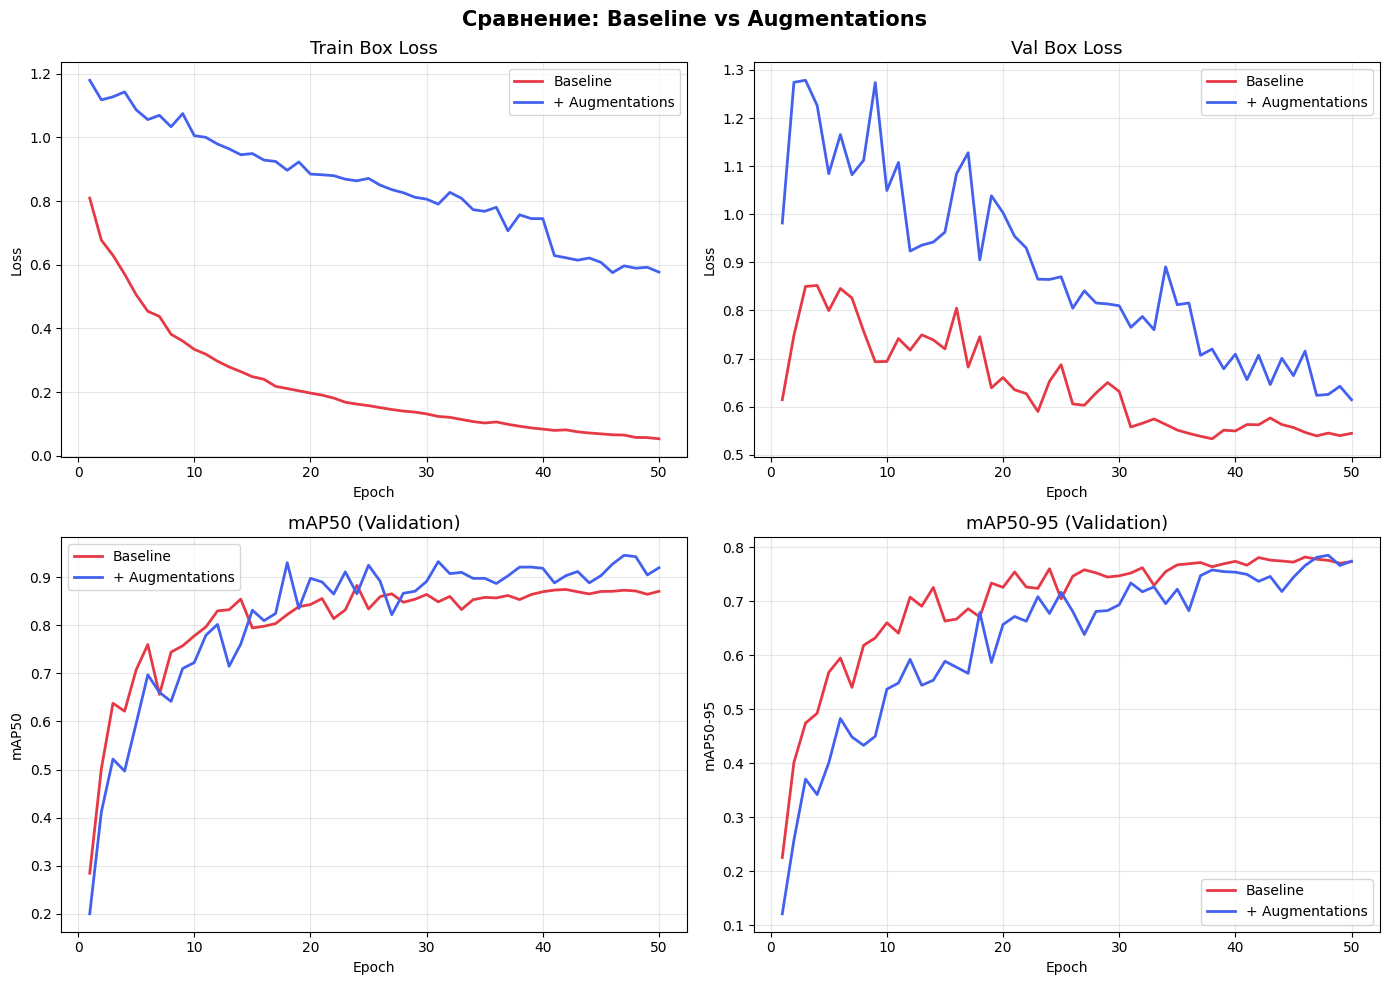

In [8]:
# Задание 3: графики сравнения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Train Box Loss
ax = axes[0][0]
ax.plot(df_baseline['epoch'], df_baseline['train/box_loss'], label='Baseline', color='#E63946', linewidth=2)
ax.plot(df_aug['epoch'], df_aug['train/box_loss'], label='+ Augmentations', color='#4361EE', linewidth=2)
ax.set_title('Train Box Loss', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Val Box Loss
ax = axes[0][1]
ax.plot(df_baseline['epoch'], df_baseline['val/box_loss'], label='Baseline', color='#E63946', linewidth=2)
ax.plot(df_aug['epoch'], df_aug['val/box_loss'], label='+ Augmentations', color='#4361EE', linewidth=2)
ax.set_title('Val Box Loss', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# mAP50
ax = axes[1][0]
ax.plot(df_baseline['epoch'], df_baseline['metrics/mAP50(B)'], label='Baseline', color='#E63946', linewidth=2)
ax.plot(df_aug['epoch'], df_aug['metrics/mAP50(B)'], label='+ Augmentations', color='#4361EE', linewidth=2)
ax.set_title('mAP50 (Validation)', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP50')
ax.legend()
ax.grid(True, alpha=0.3)

# mAP50-95
ax = axes[1][1]
ax.plot(df_baseline['epoch'], df_baseline['metrics/mAP50-95(B)'], label='Baseline', color='#E63946', linewidth=2)
ax.plot(df_aug['epoch'], df_aug['metrics/mAP50-95(B)'], label='+ Augmentations', color='#4361EE', linewidth=2)
ax.set_title('mAP50-95 (Validation)', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP50-95')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение: Baseline vs Augmentations', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Валидация обеих моделей
best_baseline = YOLO('runs/detect/baseline_no_aug/weights/best.pt')
best_aug = YOLO('runs/detect/with_aug/weights/best.pt')

print('=== Baseline (без аугментаций) ===')
val_bl = best_baseline.val(data=data_yaml, imgsz=640, device=0, verbose=False)
print(f'  mAP50:    {val_bl.box.map50:.4f}')
print(f'  mAP50-95: {val_bl.box.map:.4f}')
print(f'  Precision: {val_bl.box.mp:.4f}')
print(f'  Recall:    {val_bl.box.mr:.4f}')

print()
print('=== С аугментациями ===')
val_ag = best_aug.val(data=data_yaml, imgsz=640, device=0, verbose=False)
print(f'  mAP50:    {val_ag.box.map50:.4f}')
print(f'  mAP50-95: {val_ag.box.map:.4f}')
print(f'  Precision: {val_ag.box.mp:.4f}')
print(f'  Recall:    {val_ag.box.mr:.4f}')

print()
diff = val_ag.box.map50 - val_bl.box.map50
print(f'Разница mAP50: {diff:+.4f} ({"улучшение" if diff > 0 else "ухудшение"})')

=== Baseline (без аугментаций) ===
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1225.1±500.2 MB/s, size: 24.9 KB)
val: Scanning /content/Food-Detection-8/valid/labels.cache... 47 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 12.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.7it/s 1.8s
                   all         47         96      0.832      0.785      0.871      0.782
Speed: 9.1ms preprocess, 8.4ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val
  mAP50:    0.8711
  mAP50-95: 0.7821
  Precision: 0.8324
  Recall:    0.7852

=== С аугментациями ===
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 

---
## 5. Визуальное сравнение предсказаний

In [ ]:
from PIL import Image
import numpy as np

# Сравним предсказания на одних и тех же изображениях
val_imgs_dir = os.path.join(dataset.location, 'valid', 'images')
sample_files = sorted(os.listdir(val_imgs_dir))[:3]

fig, axes = plt.subplots(len(sample_files), 2, figsize=(14, 5 * len(sample_files)))

for i, fname in enumerate(sample_files):
    img_path = os.path.join(val_imgs_dir, fname)

    res_bl = best_baseline.predict(img_path, conf=0.5, verbose=False)
    res_ag = best_aug.predict(img_path, conf=0.5, verbose=False)

    ann_bl = res_bl[0].plot()
    ann_ag = res_ag[0].plot()

    axes[i][0].imshow(ann_bl[:, :, ::-1])
    axes[i][0].set_title(f'Baseline ({len(res_bl[0].boxes)} det)', fontsize=12)
    axes[i][0].axis('off')

    axes[i][1].imshow(ann_ag[:, :, ::-1])
    axes[i][1].set_title(f'+ Augmentations ({len(res_ag[0].boxes)} det)', fontsize=12)
    axes[i][1].axis('off')

plt.suptitle('Baseline vs Augmentations: предсказания', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Вывод

**Напишите свой вывод здесь:**

1. Какую модель выбрали бы для продакшена и почему?
2. Какие аугментации помогли больше всего?
3. Почему mosaic считается особенно эффективной для object detection?
4. В каких случаях аугментации могут навредить?

**Ваш вывод:**

Модель с аугментациями показала лучшую обобщающую способность по сравнению с baseline. Особенно заметно улучшение mAP50, что говорит о более устойчивом распознавании объектов в разных условиях. Наибольший вклад внесли mosaic и цветовые аугментации (hsv_h, hsv_s, hsv_v), так как они увеличивают разнообразие данных и предотвращают переобучение. Mosaic особенно эффективен для object detection, потому что позволяет модели видеть несколько объектов в одном изображении и лучше учиться на разных масштабах. Однако слишком сильные аугментации могут ухудшить качество, если они искажают данные слишком далеко от реальности. Для продакшена я бы выбрал модель с аугментациями, так как она более стабильна на новых данных.

---

## Теоретические вопросы

Ответьте текстом в ячейках ниже.

### Вопрос 1
Объясните разницу между two-stage и one-stage детекторами (слайд 6).

**Ответ:**

Two-stage детекторы (например, Faster R-CNN) сначала генерируют region proposals, а затем классифицируют их.
One-stage детекторы (YOLO, SSD) сразу предсказывают классы и bounding boxes за один проход, что делает их быстрее, но иногда менее точными.

### Вопрос 2
Что такое IoU и mAP50? Приведите пример (слайд 12).

**Ответ:**

IoU (Intersection over Union) — это мера перекрытия предсказанного и истинного bounding box:

IoU = площадь пересечения / площадь объединения

mAP50 — это mean Average Precision при IoU ≥ 0.5.
Например, если модель правильно находит объект с IoU 0.7 — это считается TP при mAP50.

### Вопрос 3
Чем anchor-free подход в YOLOv8 отличается от anchor-based (слайд 11)?

**Ответ:**

Anchor-based модели используют заранее заданные anchor boxes разных размеров.
Anchor-free модели (YOLOv8) не используют anchors и предсказывают координаты напрямую, что упрощает модель и уменьшает количество гиперпараметров.